<a href="https://colab.research.google.com/github/MahinourAbdelgawad/Plant-Disease-Detection/blob/main/plant_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Species and Disease Detection
Possible scopes:
- Predict species
- Predict diseased or healthy
- Predict diseased or healthy given species
- Predict disease
- Predict disease given species

Methods?
- Classical CV: Can predict diseased vs. healthy by detecting color shifts (green vs brown spots) and leaf shapes, but completely blind to the small differences between specific diseases or plant species
- Classical ML: Can predict diseased vs. healthy, predict species, and predict disease given species if a human manually calculates and inputs the mathematical features (like texture math or spot sizes)
- Deep Learning: Can do all scopes

Possible paths:
- Predict diseased or healthy using classical CV and then classical ML and then DL and compare

### STEP 0: Load dataset, examine data, and preprocess

In [4]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [7]:
import kagglehub

path = kagglehub.dataset_download("riteshmaurya86/cleaned-plant-disease-image-dataset")

print("Dataset downloaded to:", path)

100%|██████████| 1.34G/1.34G [00:59<00:00, 24.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/riteshmaurya86/cleaned-plant-disease-image-dataset/versions/1


In [8]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/PlantDetection'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [9]:
# check out the dataset
import os

DATA_DIR = os.path.join(path, 'data')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Number of classes: {len(classes)}")
for c in classes:
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f"{c}: {n} images")

Number of classes: 38
Apple___Apple_scab: 2016 images
Apple___Black_rot: 1987 images
Apple___Cedar_apple_rust: 1760 images
Apple___healthy: 2008 images
Blueberry___healthy: 1816 images
Cherry_(including_sour)___Powdery_mildew: 1683 images
Cherry_(including_sour)___healthy: 1826 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
Corn_(maize)___Common_rust_: 1907 images
Corn_(maize)___Northern_Leaf_Blight: 1908 images
Corn_(maize)___healthy: 1859 images
Grape___Black_rot: 1888 images
Grape___Esca_(Black_Measles): 1920 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 images
Grape___healthy: 1692 images
Orange___Haunglongbing_(Citrus_greening): 2010 images
Peach___Bacterial_spot: 1838 images
Peach___healthy: 1728 images
Pepper,_bell___Bacterial_spot: 1913 images
Pepper,_bell___healthy: 1988 images
Potato___Early_blight: 1939 images
Potato___Late_blight: 1939 images
Potato___healthy: 1824 images
Raspberry___healthy: 1781 images
Soybean___healthy: 2022 images
Squas

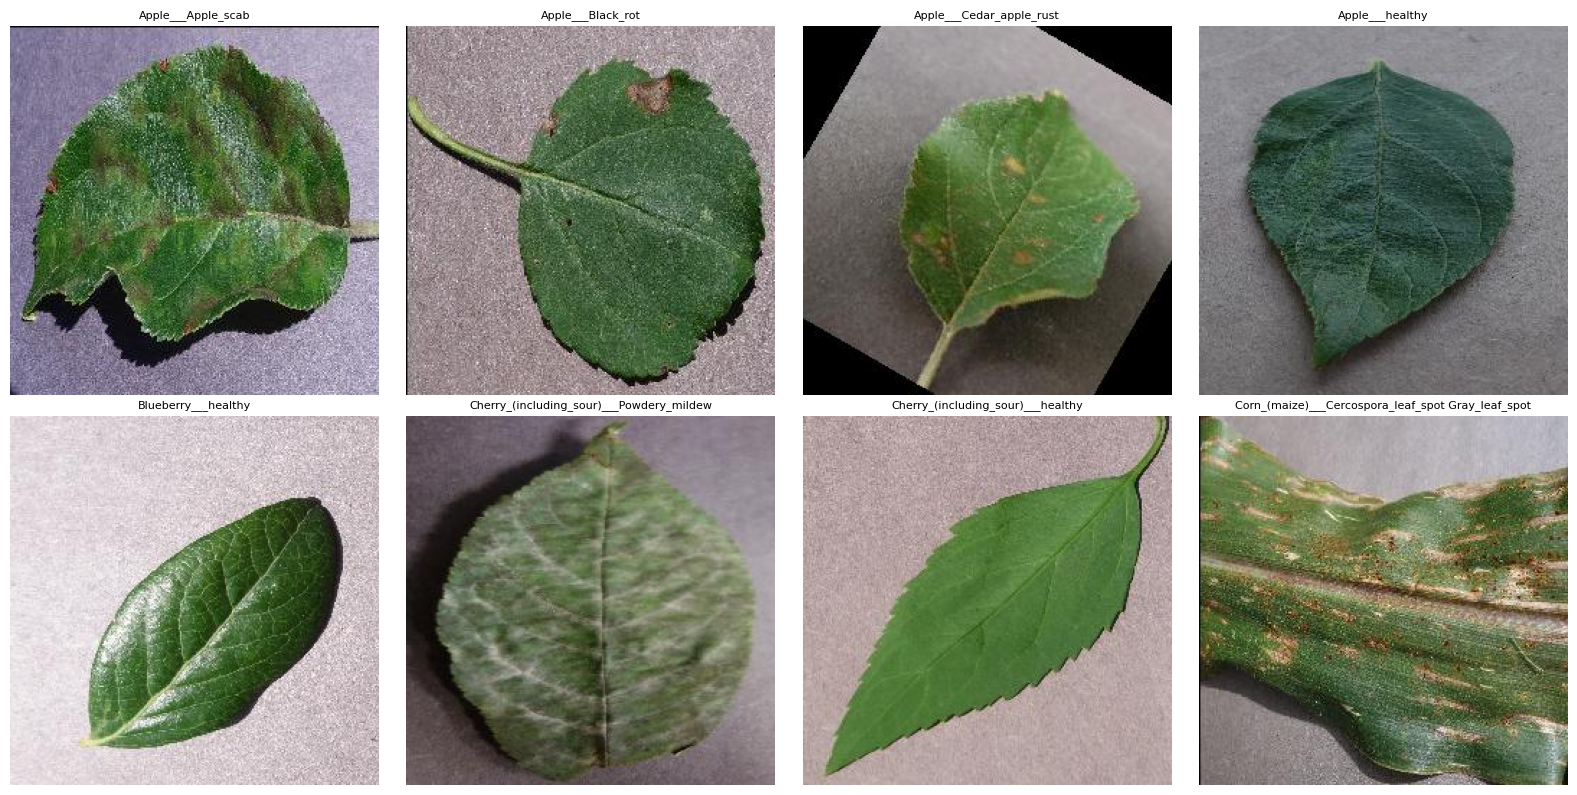

In [10]:
# visualize some samples
import matplotlib.pyplot as plt
import cv2 as cv

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = classes[:8]

for ax, c in zip(axes.flat, sample_classes):
    img_name = os.listdir(os.path.join(TRAIN_DIR, c))[0]
    img = cv.imread(os.path.join(TRAIN_DIR, c, img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(c, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# dataset summary
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_list = []
for c in classes:
    num_images = len(os.listdir(os.path.join(TRAIN_DIR, c)))


    if "___" in c:
        plant, disease = c.split("___")
    else:
        plant, disease = c, "Unknown"

    data_list.append({
        'Folder_Name': c,
        'Plant': plant.replace('_', ' '),
        'Condition': disease.replace('_', ' '),
        'Image_Count': num_images
    })

df = pd.DataFrame(data_list)

total_images = df['Image_Count'].sum()
unique_plants = df['Plant'].nunique()
unique_conditions = df[df['Condition'] != 'healthy']['Condition'].nunique()

print("="*40)
print(f"DATASET SUMMARY")
print("="*40)
print(f"Total Images: {total_images:,}")
print(f"Unique Plants: {unique_plants} {df['Plant'].unique().tolist()}")
print(f"Unique Diseases: {unique_conditions}")
print(f"Average images/class: {df['Image_Count'].mean():.1f}")
print("="*40)

DATASET SUMMARY
Total Images: 70,295
Unique Plants: 14 ['Apple', 'Blueberry', 'Cherry (including sour)', 'Corn (maize)', 'Grape', 'Orange', 'Peach', 'Pepper, bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']
Unique Diseases: 20
Average images/class: 1849.9


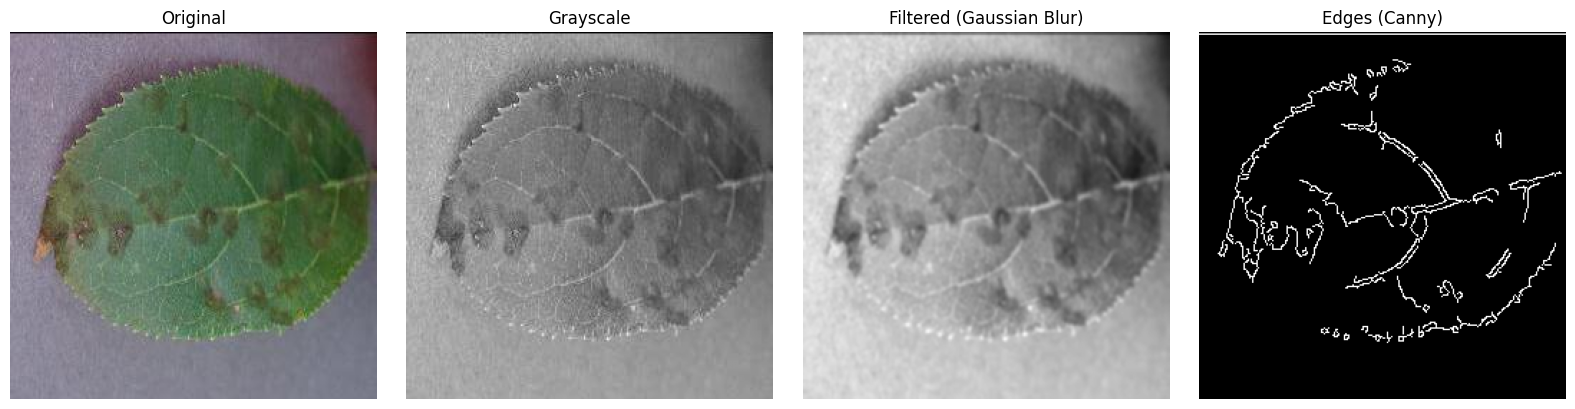

In [34]:
# experimemt with preprocessing
class_index = 0
image_index = 777

canny_threshold1 = 40
canny_threshold2 = 100

img = cv.imread(os.path.join(TRAIN_DIR, classes[class_index], os.listdir(os.path.join(TRAIN_DIR, classes[class_index]))[image_index]))

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Grayscale
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

# Gaussian filter
blurred = cv.GaussianBlur(gray, (5, 5), 0)

# Canny edge detectio
edges = cv.Canny(blurred, threshold1=canny_threshold1, threshold2=canny_threshold2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'Grayscale', 'Filtered (Gaussian Blur)', 'Edges (Canny)']
imgs = [img, gray, blurred, edges]
cmaps = [None, 'gray', 'gray', 'gray']
for ax, im, t, cm in zip(axes, imgs, titles, cmaps):
    ax.imshow(im, cmap=cm)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(path):
  #TODO: come back to this, what preprocessing will we really need????
  img = cv.imread(path)
  img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  # img = cv.resize(img, size)

  canny_threshold1 = 40
  canny_threshold2 = 100

  gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
  blurred = cv.GaussianBlur(gray, (5, 5), 0)
  edges = cv.Canny(blurred, canny_threshold1, canny_threshold2)

  return img, gray, blurred, edges

## GOAL 1: DISEASED VS HEALTHY

### Step 1: Classical CV only

### Step 2: Classical ML

### Step 3: Deep Learning